In [2]:
#1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

In [3]:
#2. Load Datasets
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")
gs    = pd.read_csv("gender_submission.csv")

print(f"Train  shape : {train.shape}")
print(f"Test   shape : {test.shape}")
print(f"Gender sub   : {gs.shape}")
train.head()


Train  shape : (891, 12)
Test   shape : (418, 11)
Gender sub   : (418, 2)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1 · Dataset Overview

In [4]:
#3. Basic Info
print("=" * 55)
print("TRAIN  INFO")
print("=" * 55)
train.info()
print()

TRAIN  INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB



In [5]:
#4. Statistical Summary
train.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


## 2 · Missing Value Analysis

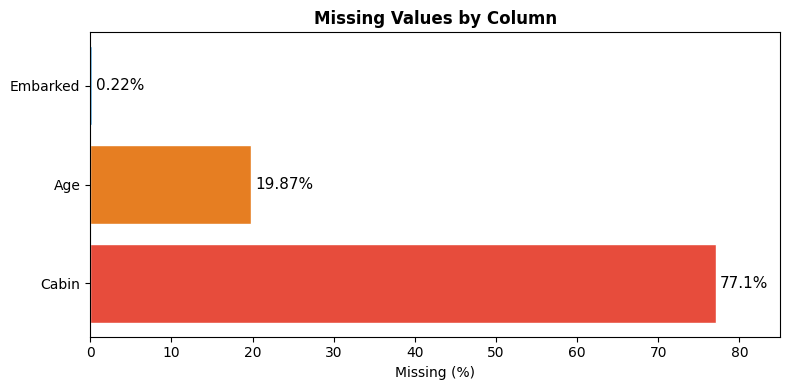

  Column  Missing  Pct (%)
   Cabin      687    77.10
     Age      177    19.87
Embarked        2     0.22


In [6]:
#5. Missing Values
missing = (train.isnull().sum()
           .reset_index()
           .rename(columns={0: "Missing", "index": "Column"}))
missing["Pct (%)"] = (missing["Missing"] / len(train) * 100).round(2)
missing = missing[missing["Missing"] > 0].sort_values("Pct (%)", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(missing["Column"], missing["Pct (%)"],
               color=["#e74c3c", "#e67e22", "#3498db"], edgecolor="white")
for bar, pct in zip(bars, missing["Pct (%)"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{pct}%", va="center", fontsize=11)
ax.set_xlabel("Missing (%)")
ax.set_title("Missing Values by Column", fontweight="bold")
ax.set_xlim(0, 85)
plt.tight_layout()
plt.savefig("plot_missing.png", dpi=120)
plt.show()

print(missing.to_string(index=False))


## 3 · Univariate Analysis

/tmp/ipykernel_1435/2647610889.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Survived", data=train, palette=["#e74c3c", "#2ecc71"],
/tmp/ipykernel_1435/2647610889.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Did Not Survive (0)", "Survived (1)"])


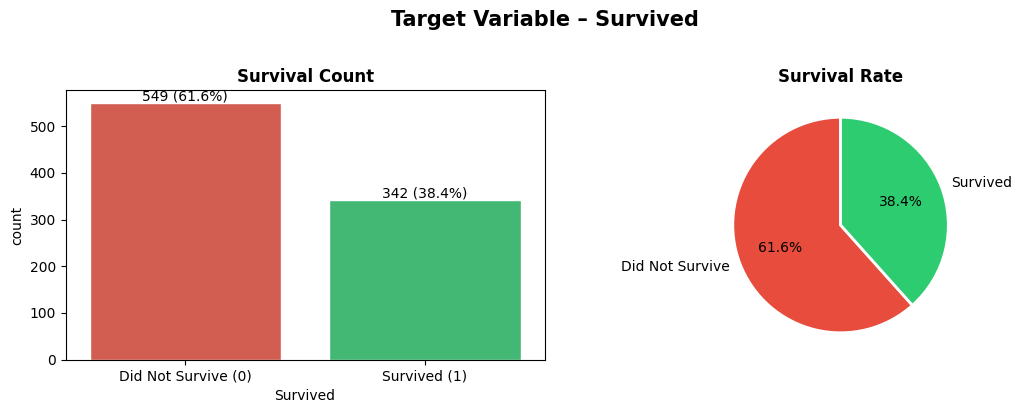

In [7]:
#6. Survival Distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Count plot
sns.countplot(x="Survived", data=train, palette=["#e74c3c", "#2ecc71"],
              ax=axes[0], edgecolor="white")
axes[0].set_xticklabels(["Did Not Survive (0)", "Survived (1)"])
axes[0].set_title("Survival Count", fontweight="bold")
for p in axes[0].patches:
    axes[0].text(p.get_x() + p.get_width() / 2, p.get_height() + 5,
                 f"{int(p.get_height())} ({p.get_height()/len(train)*100:.1f}%)",
                 ha="center", fontsize=10)

# Pie
survived_counts = train["Survived"].value_counts()
axes[1].pie(survived_counts, labels=["Did Not Survive", "Survived"],
            autopct="%1.1f%%", colors=["#e74c3c", "#2ecc71"],
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Survival Rate", fontweight="bold")

plt.suptitle("Target Variable – Survived", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("plot_survival.png", dpi=120)
plt.show()


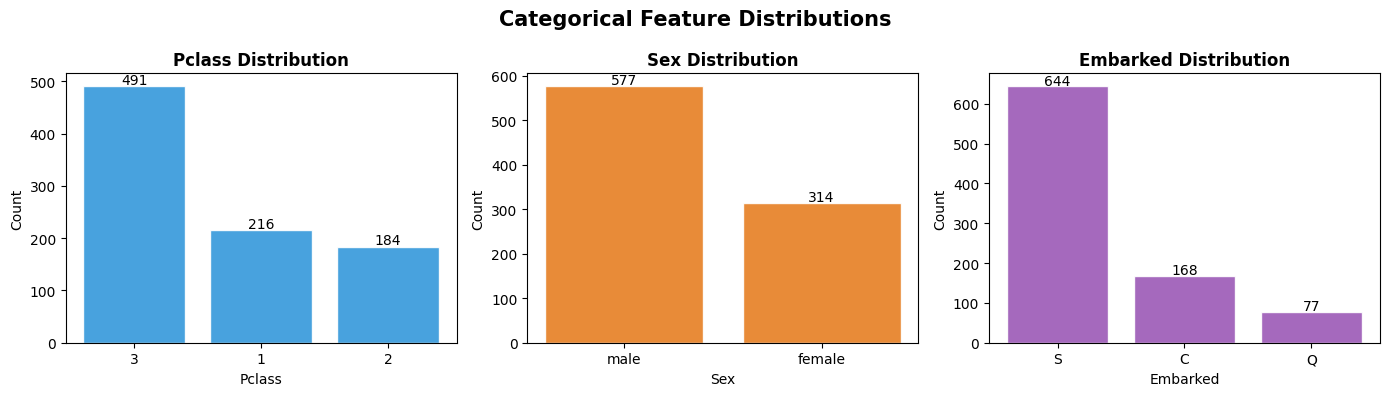


Pclass value_counts:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Sex value_counts:
Sex
male      577
female    314
Name: count, dtype: int64

Embarked value_counts:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [8]:
#7. Categorical Features – value_counts
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cat_cols = ["Pclass", "Sex", "Embarked"]
palette  = ["#3498db", "#e67e22", "#9b59b6"]

for ax, col, pal in zip(axes, cat_cols, palette):
    vc = train[col].value_counts()
    ax.bar(vc.index.astype(str), vc.values, color=pal, edgecolor="white", alpha=0.9)
    ax.set_title(f"{col} Distribution", fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    for i, v in enumerate(vc.values):
        ax.text(i, v + 4, str(v), ha="center", fontsize=10)

plt.suptitle("Categorical Feature Distributions", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_categorical.png", dpi=120)
plt.show()

for col in cat_cols:
    print(f"\n{col} value_counts:\n{train[col].value_counts()}")


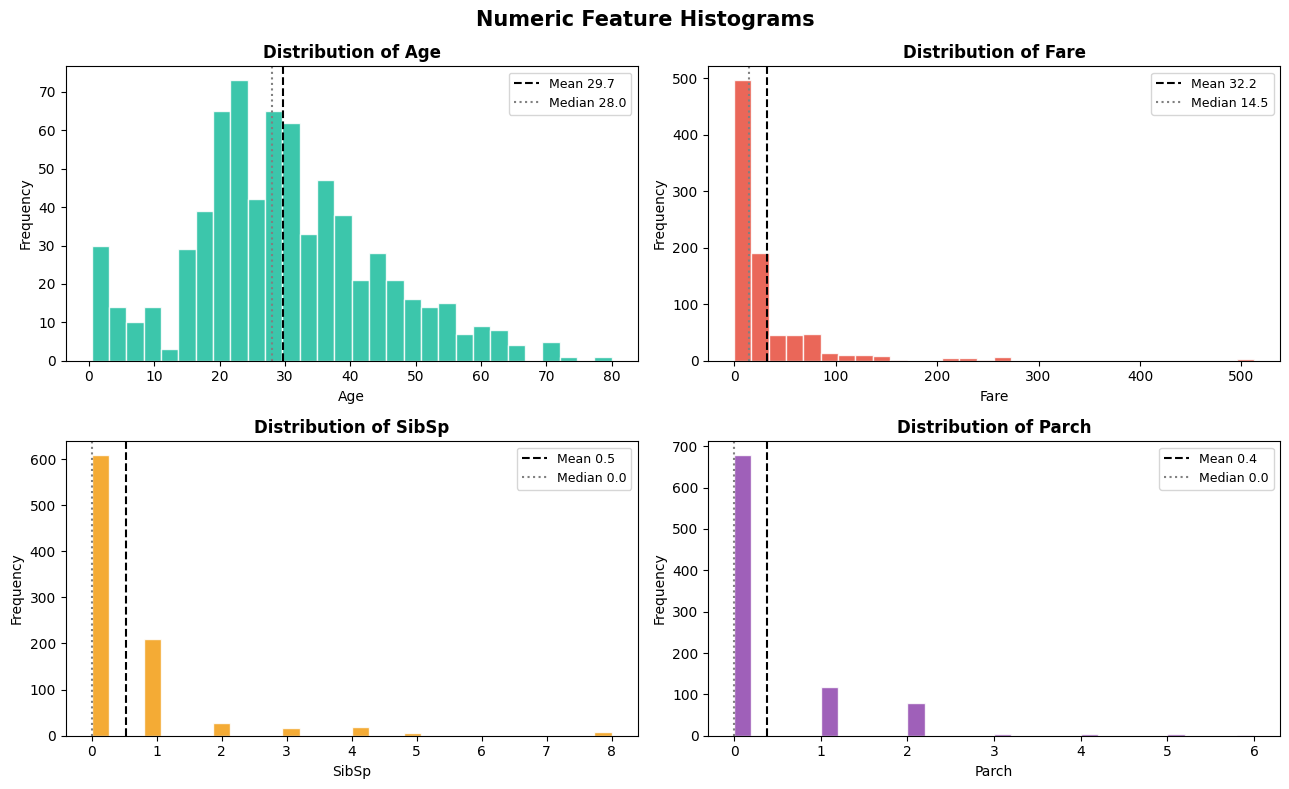

In [9]:
# 8. Numeric Feature Distributions (Histograms)
num_cols = ["Age", "Fare", "SibSp", "Parch"]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
colors = ["#1abc9c", "#e74c3c", "#f39c12", "#8e44ad"]

for ax, col, clr in zip(axes.flatten(), num_cols, colors):
    data = train[col].dropna()
    ax.hist(data, bins=30, color=clr, edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(),   color="black", linestyle="--", lw=1.5, label=f"Mean {data.mean():.1f}")
    ax.axvline(data.median(), color="grey",  linestyle=":",  lw=1.5, label=f"Median {data.median():.1f}")
    ax.set_title(f"Distribution of {col}", fontweight="bold")
    ax.set_xlabel(col); ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

plt.suptitle("Numeric Feature Histograms", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_histograms.png", dpi=120)
plt.show()


## 4 · Bivariate Analysis

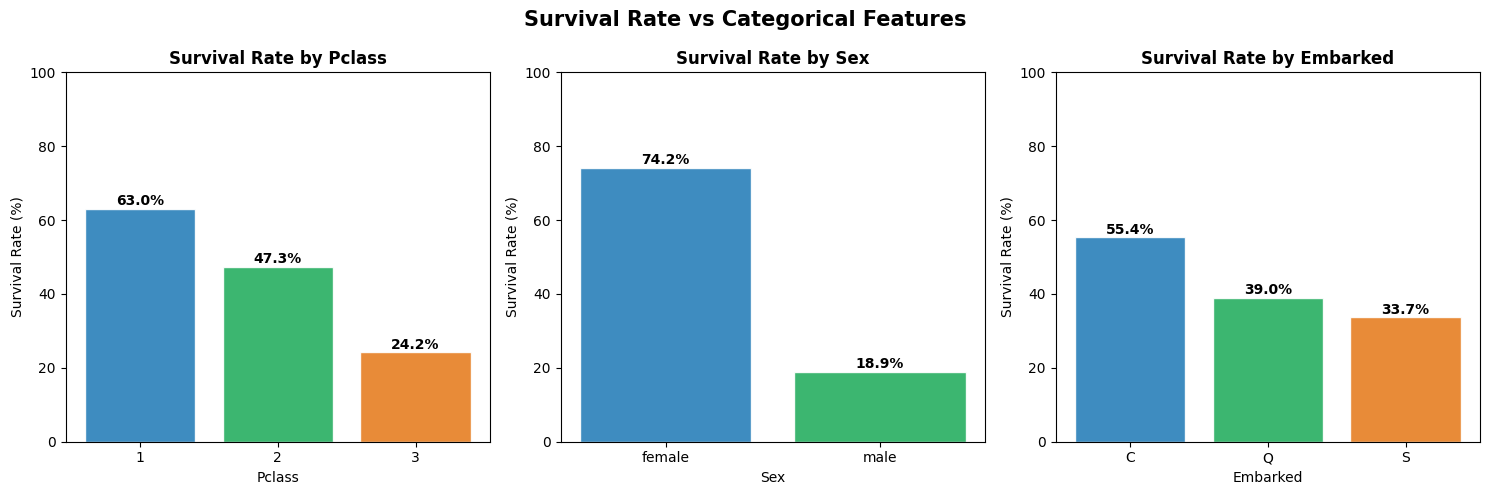

In [10]:
#9. Survival vs Categorical Features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ["Pclass", "Sex", "Embarked"]):
    survival_rate = train.groupby(col)["Survived"].mean().reset_index()
    survival_rate["Survived"] *= 100
    bars = ax.bar(survival_rate[col].astype(str), survival_rate["Survived"],
                  color=["#2980b9", "#27ae60", "#e67e22"][:len(survival_rate)],
                  edgecolor="white", alpha=0.9)
    for bar, val in zip(bars, survival_rate["Survived"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")
    ax.set_ylim(0, 100)
    ax.set_title(f"Survival Rate by {col}", fontweight="bold")
    ax.set_xlabel(col); ax.set_ylabel("Survival Rate (%)")

plt.suptitle("Survival Rate vs Categorical Features", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_survival_cat.png", dpi=120)
plt.show()


/tmp/ipykernel_1435/2910217561.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Survived", y=col, data=train, palette=pal,
/tmp/ipykernel_1435/2910217561.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Did Not Survive", "Survived"])
/tmp/ipykernel_1435/2910217561.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Survived", y=col, data=train, palette=pal,
/tmp/ipykernel_1435/2910217561.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Did Not Survive", "Survived"])


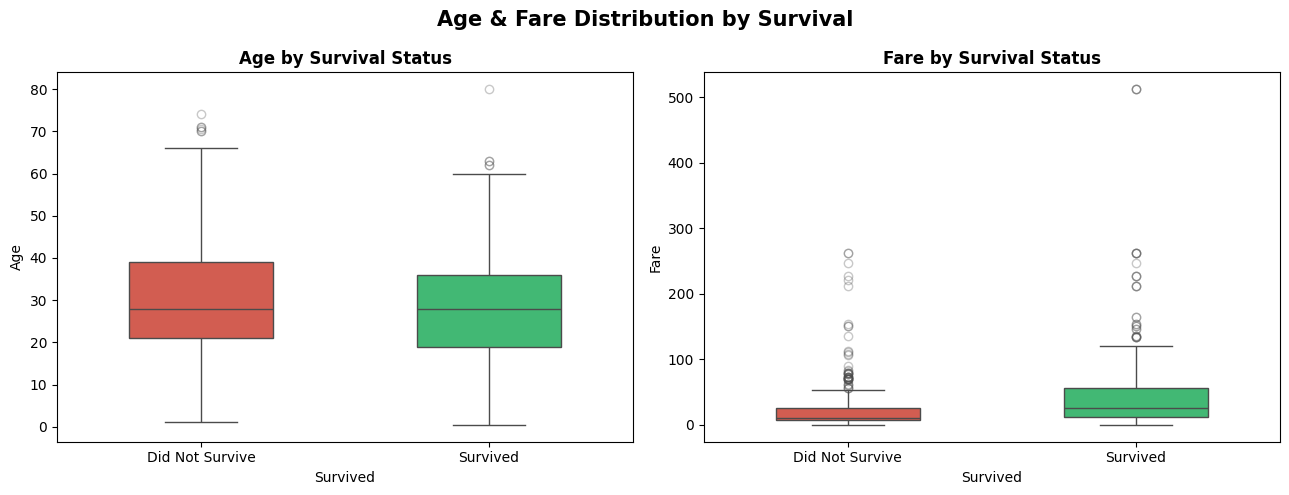

In [11]:
# 10. Boxplots – Age & Fare by Survival
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, pal in zip(axes, ["Age", "Fare"], [["#e74c3c","#2ecc71"], ["#e74c3c","#2ecc71"]]):
    sns.boxplot(x="Survived", y=col, data=train, palette=pal,
                ax=ax, width=0.5, flierprops=dict(marker="o", alpha=0.3))
    ax.set_xticklabels(["Did Not Survive", "Survived"])
    ax.set_title(f"{col} by Survival Status", fontweight="bold")

plt.suptitle("Age & Fare Distribution by Survival", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_boxplots.png", dpi=120)
plt.show()


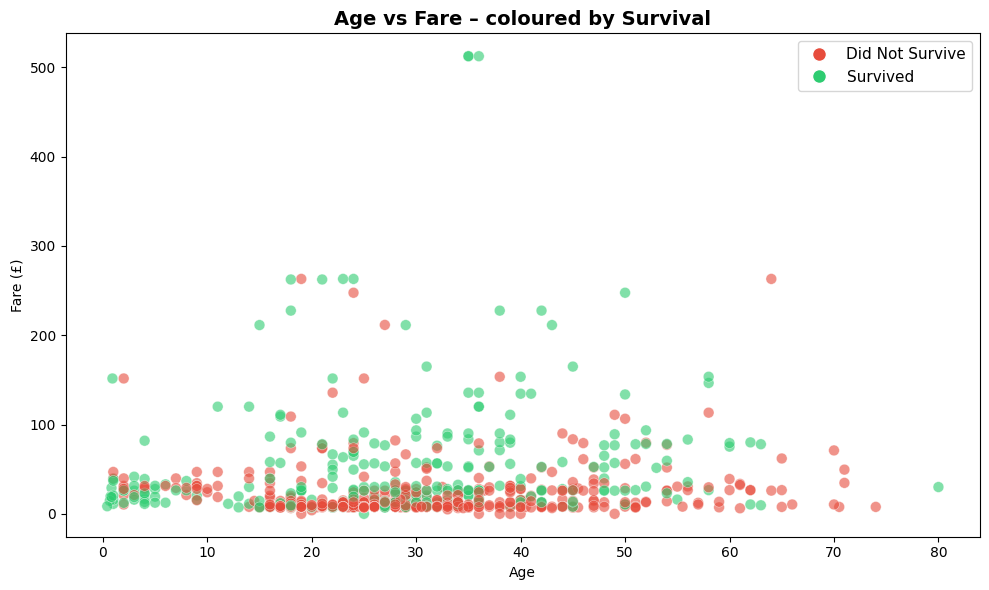

In [12]:
#11. Scatterplot – Age vs Fare coloured by Survival
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    x=train["Age"],
    y=train["Fare"],
    c=train["Survived"].map({0: "#e74c3c", 1: "#2ecc71"}),
    alpha=0.6, edgecolors="white", linewidths=0.4, s=60
)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", label="Did Not Survive",
           markerfacecolor="#e74c3c", markersize=10),
    Line2D([0], [0], marker="o", color="w", label="Survived",
           markerfacecolor="#2ecc71", markersize=10),
]
ax.legend(handles=legend_elements, fontsize=11)
ax.set_xlabel("Age"); ax.set_ylabel("Fare (£)")
ax.set_title("Age vs Fare – coloured by Survival", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig("plot_scatter.png", dpi=120)
plt.show()


## 5 · Multivariate Analysis

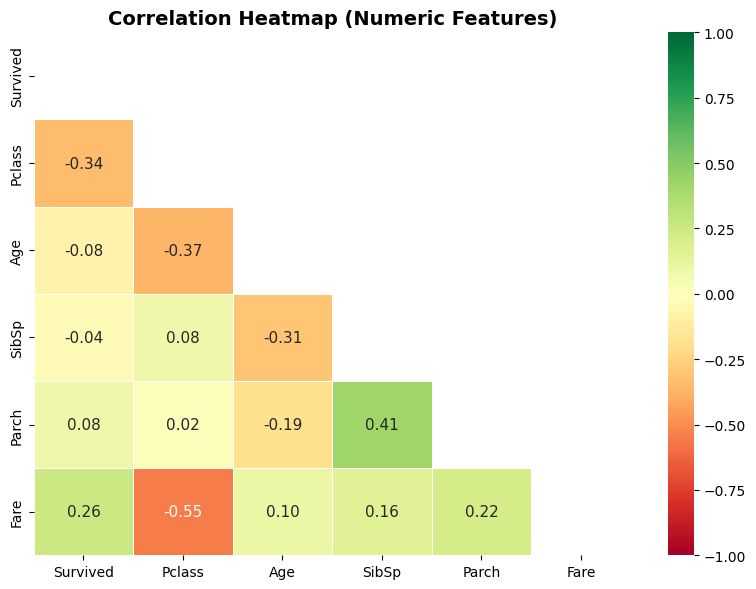

Top correlations with Survived:
Pclass   -0.338481
Fare      0.257307
Parch     0.081629
Age      -0.077221
SibSp    -0.035322
Name: Survived, dtype: float64


In [13]:
# 12. Correlation Heatmap
numeric_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
corr = train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax,
            annot_kws={"size": 11})
ax.set_title("Correlation Heatmap (Numeric Features)", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig("plot_heatmap.png", dpi=120)
plt.show()

print("Top correlations with Survived:")
print(corr["Survived"].drop("Survived").sort_values(key=abs, ascending=False))


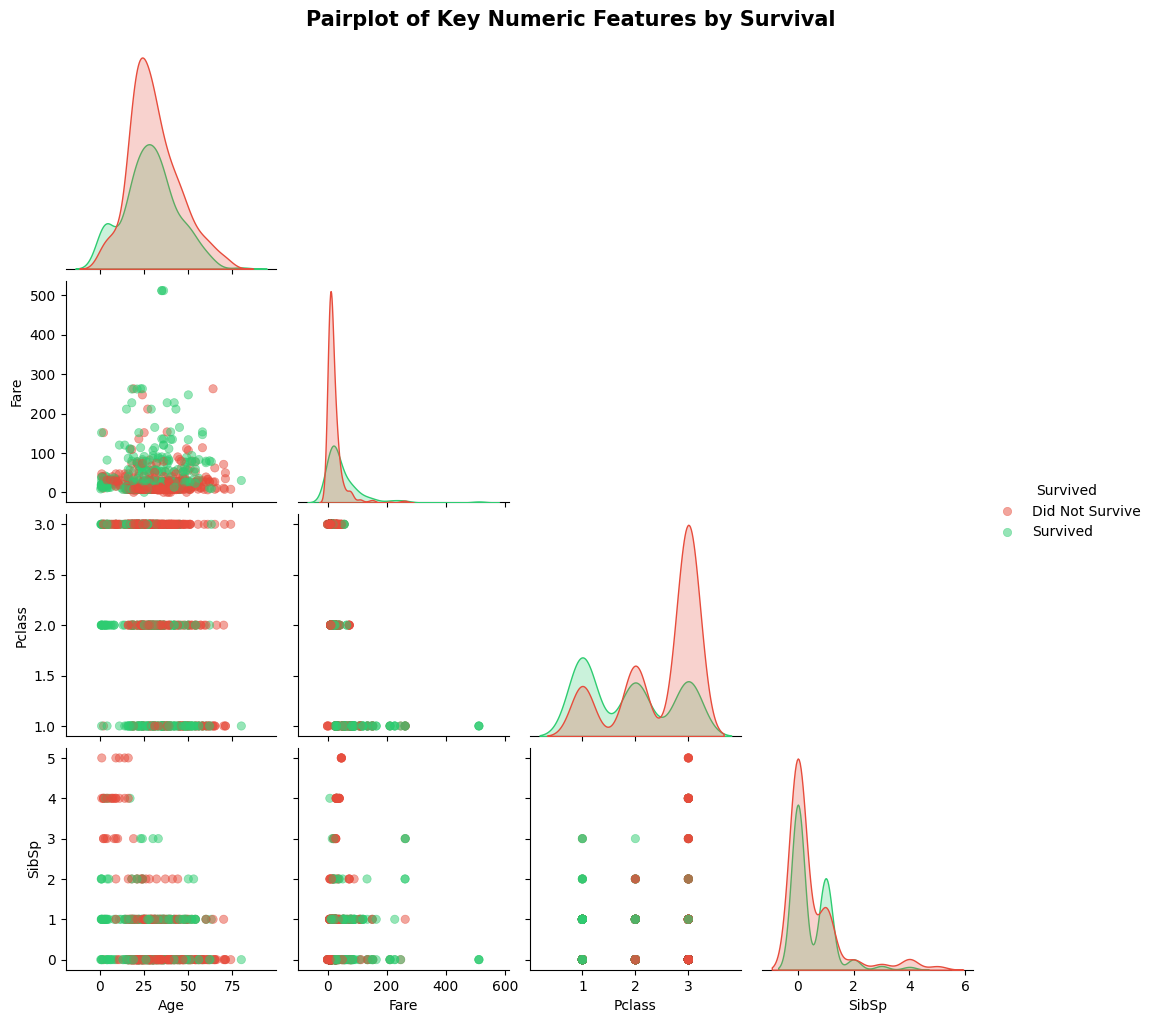

In [14]:
# 13. Pairplot
pair_data = train[["Age", "Fare", "Pclass", "SibSp", "Survived"]].dropna()
pair_data["Survived"] = pair_data["Survived"].map({0: "Did Not Survive", 1: "Survived"})

g = sns.pairplot(pair_data, hue="Survived",
                 palette={"Did Not Survive": "#e74c3c", "Survived": "#2ecc71"},
                 plot_kws={"alpha": 0.5, "edgecolor": None},
                 diag_kind="kde", corner=True, height=2.5)
g.fig.suptitle("Pairplot of Key Numeric Features by Survival",
               fontsize=15, fontweight="bold", y=1.02)
g.fig.savefig("plot_pairplot.png", dpi=100, bbox_inches="tight")
plt.show()


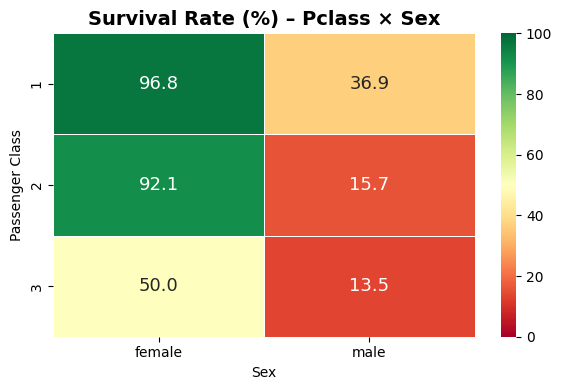

In [15]:
# 14. Survival Rate Heatmap: Pclass × Sex
pivot = train.pivot_table(index="Pclass", columns="Sex",
                          values="Survived", aggfunc="mean")
pivot = (pivot * 100).round(1)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn",
            linewidths=0.5, vmin=0, vmax=100, ax=ax,
            annot_kws={"size": 13})
ax.set_title("Survival Rate (%) – Pclass × Sex", fontweight="bold", fontsize=14)
ax.set_xlabel("Sex"); ax.set_ylabel("Passenger Class")
plt.tight_layout()
plt.savefig("plot_pclass_sex.png", dpi=120)
plt.show()


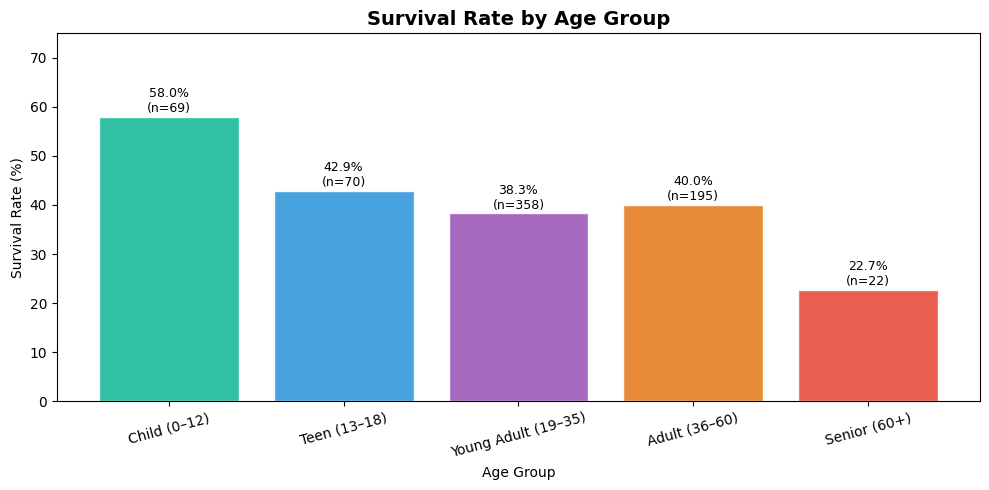

In [16]:
# 15. Survival by Age Group
train2 = train.copy()
train2["AgeGroup"] = pd.cut(train2["Age"],
                            bins=[0, 12, 18, 35, 60, 100],
                            labels=["Child (0–12)", "Teen (13–18)",
                                    "Young Adult (19–35)",
                                    "Adult (36–60)", "Senior (60+)"])

age_surv = (train2.groupby("AgeGroup", observed=True)["Survived"]
            .agg(["mean", "count"])
            .reset_index())
age_surv["mean"] *= 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(age_surv["AgeGroup"], age_surv["mean"],
              color=["#1abc9c", "#3498db", "#9b59b6", "#e67e22", "#e74c3c"],
              edgecolor="white", alpha=0.9)
for bar, (mean, cnt) in zip(bars, zip(age_surv["mean"], age_surv["count"])):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{mean:.1f}%\n(n={cnt})", ha="center", fontsize=9)
ax.set_ylim(0, 75)
ax.set_title("Survival Rate by Age Group", fontweight="bold", fontsize=14)
ax.set_xlabel("Age Group"); ax.set_ylabel("Survival Rate (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("plot_agegroup.png", dpi=120)
plt.show()


## 6 · Skewness & Outlier Detection

Skewness of numeric features:
Fare     4.787317
SibSp    3.695352
Parch    2.749117
Age      0.389108
dtype: float64


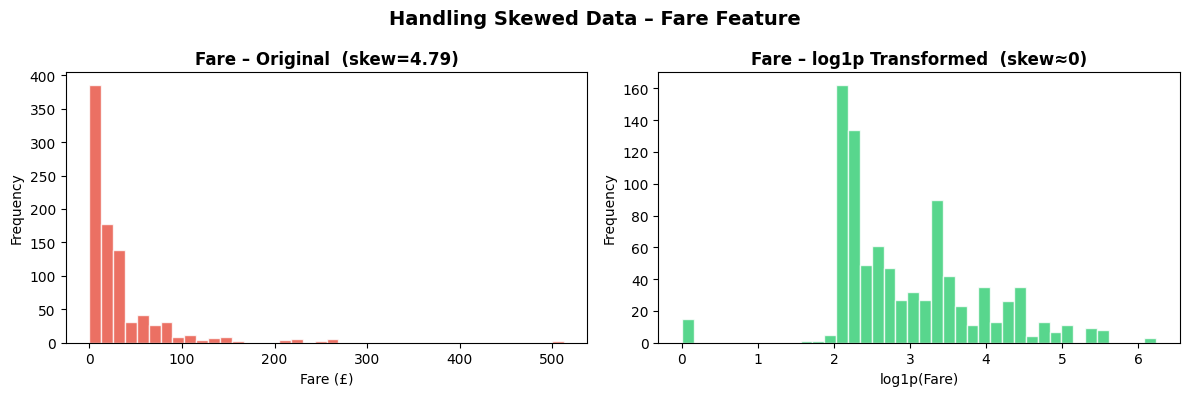

In [17]:
#16. Skewness
num_cols = ["Age", "Fare", "SibSp", "Parch"]
skew_vals = train[num_cols].skew().sort_values(ascending=False)
print("Skewness of numeric features:")
print(skew_vals)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original Fare
axes[0].hist(train["Fare"].dropna(), bins=40, color="#e74c3c", edgecolor="white", alpha=0.8)
axes[0].set_title(f"Fare – Original  (skew={train['Fare'].skew():.2f})", fontweight="bold")
axes[0].set_xlabel("Fare (£)"); axes[0].set_ylabel("Frequency")

# Log-transformed Fare
axes[1].hist(np.log1p(train["Fare"].dropna()), bins=40, color="#2ecc71", edgecolor="white", alpha=0.8)
axes[1].set_title("Fare – log1p Transformed  (skew≈0)", fontweight="bold")
axes[1].set_xlabel("log1p(Fare)"); axes[1].set_ylabel("Frequency")

plt.suptitle("Handling Skewed Data – Fare Feature", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_skew.png", dpi=120)
plt.show()


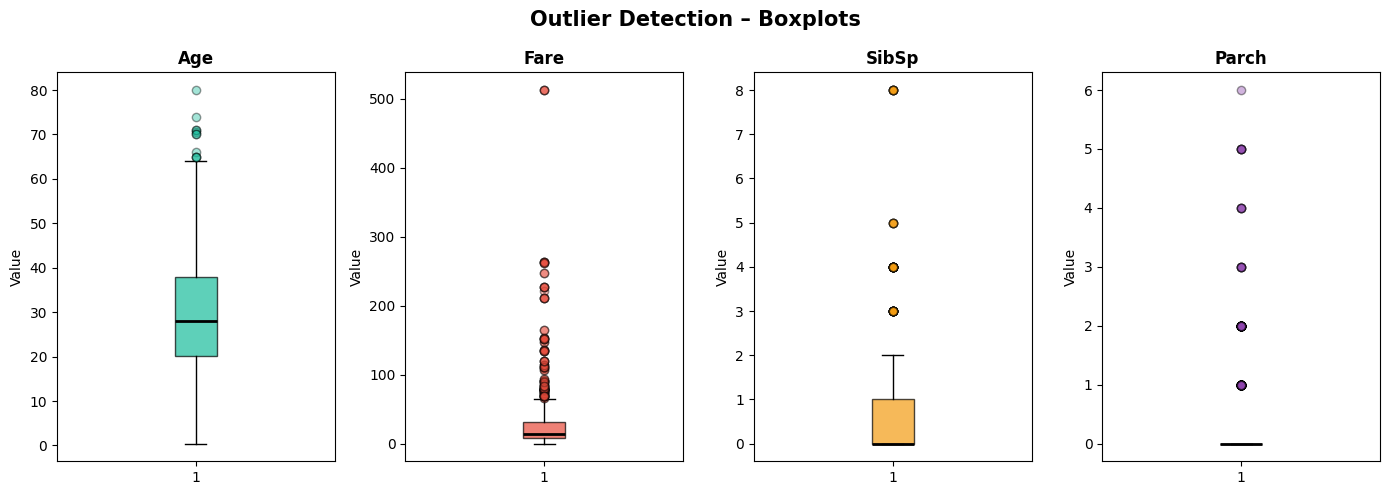

In [18]:
#17. Outlier Detection via Boxplots
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
colors = ["#1abc9c", "#e74c3c", "#f39c12", "#8e44ad"]

for ax, col, clr in zip(axes, ["Age", "Fare", "SibSp", "Parch"], colors):
    ax.boxplot(train[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=clr, alpha=0.7),
               medianprops=dict(color="black", linewidth=2),
               flierprops=dict(marker="o", markerfacecolor=clr, alpha=0.4))
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("Value")

plt.suptitle("Outlier Detection – Boxplots", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_outliers.png", dpi=120)
plt.show()


## 7 · Feature Engineering Insight

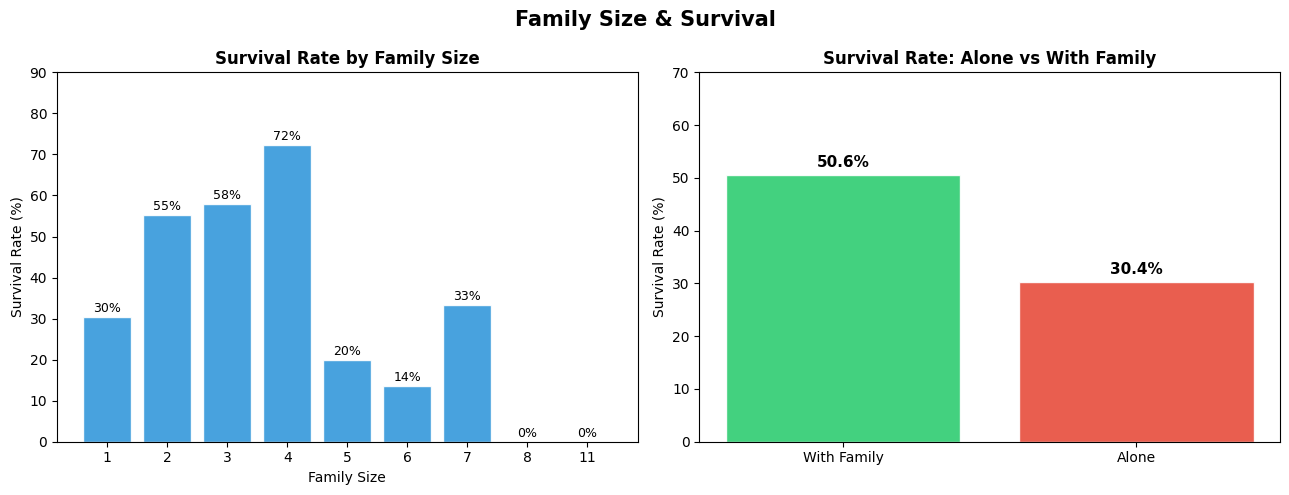


IsAlone vs Survived value_counts:

IsAlone  Survived
0        1           179
         0           175
1        0           374
         1           163
Name: count, dtype: int64


In [19]:
#18. Family Size Feature
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1
train["IsAlone"]    = (train["FamilySize"] == 1).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Survival by FamilySize
fs_surv = train.groupby("FamilySize")["Survived"].mean() * 100
axes[0].bar(fs_surv.index.astype(str), fs_surv.values,
            color="#3498db", edgecolor="white", alpha=0.9)
for i, v in enumerate(fs_surv.values):
    axes[0].text(i, v + 1.2, f"{v:.0f}%", ha="center", fontsize=9)
axes[0].set_title("Survival Rate by Family Size", fontweight="bold")
axes[0].set_xlabel("Family Size"); axes[0].set_ylabel("Survival Rate (%)")
axes[0].set_ylim(0, 90)

# Alone vs Not Alone
alone_surv = train.groupby("IsAlone")["Survived"].mean() * 100
axes[1].bar(["With Family", "Alone"],
            [alone_surv.get(0, 0), alone_surv.get(1, 0)],
            color=["#2ecc71", "#e74c3c"], edgecolor="white", alpha=0.9)
for i, v in enumerate([alone_surv.get(0, 0), alone_surv.get(1, 0)]):
    axes[1].text(i, v + 1.5, f"{v:.1f}%", ha="center", fontsize=11, fontweight="bold")
axes[1].set_title("Survival Rate: Alone vs With Family", fontweight="bold")
axes[1].set_ylabel("Survival Rate (%)"); axes[1].set_ylim(0, 70)

plt.suptitle("Family Size & Survival", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_family.png", dpi=120)
plt.show()

print("\nIsAlone vs Survived value_counts:\n")
print(train.groupby("IsAlone")["Survived"].value_counts())


---

## 8 · Summary of Key Findings

| # | Finding | Key Metric |
|---|---------|-----------|
| 1 | Overall survival rate is low | **38.4 %** survived |
| 2 | Gender is the strongest predictor | Female: **74 %** vs Male: **19 %** |
| 3 | Passenger class is critical | 1st: **63 %** vs 3rd: **24 %** |
| 4 | Fare and survival are positively linked | Correlation = **+0.26** |
| 5 | Children were prioritised | Ages 0–12: **59.4 %** survival |
| 6 | Travelling with family helps | Solo: **30 %** vs With family: **51 %** |
| 7 | Cabin data is too sparse to use directly | **77 %** missing |
| 8 | Fare is heavily right-skewed | Skew = **4.79** → use log1p |
| 9 | Cherbourg boarders survived more | **~55 %** vs Southampton ~34 % |
| 10 | 1st class females had near-perfect survival | **96.8 %** |

---